# Country Development Clustering Project

In this project, we analyze socio-economic and health indicators of 167 countries to identify patterns of development using clustering techniques.

The goal is to group countries based on their development profile and recommend which countries are in the most urgent need of financial aid for humanitarian support.

## Data Loading

In this step, we load the dataset and convert it into a Pandas DataFrame for further analysis and preprocessing.

In [1]:
import os
import pandas as pd

path = os.path.join("..", "data", "Country-data.csv")
df = pd.read_csv(path)

## Feature Transformation

Some variables (`exports`, `imports`, `health`) are provided as percentages of GDP. In this step, we convert them into absolute values using GDP per capita to make them more meaningful and consistent for further analysis.

In [2]:
df['exports'] = df['exports'] * df['gdpp'] / 100
df['imports'] = df['imports'] * df['gdpp'] / 100
df['health']  = df['health']  * df['gdpp'] / 100

## Initial Data Inspection

We now explore the dataset structure using basic Pandas functions such as `head()`, `info()`, and `describe()` to understand the data types, summary statistics, and overall structure.

In [3]:
df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,55.30,41.9174,248.297,1610,9.440,56.2,5.82,553
1,Albania,16.6,1145.20,267.8950,1987.740,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,1712.64,185.9820,1400.440,12900,16.100,76.5,2.89,4460
3,Angola,119.0,2199.19,100.6050,1514.370,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,5551.00,735.6600,7185.800,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,1946.70,834.3000,1648.000,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,669.76,141.6800,1458.660,6700,7.770,73.3,1.69,3220
7,Australia,4.8,10276.20,4530.8700,10847.100,41400,1.160,82.0,1.93,51900
8,Austria,4.3,24059.70,5159.0000,22418.200,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,3171.12,343.3920,1208.880,16000,13.800,69.1,1.92,5840


In [4]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,7420.618847,1056.733204,6588.352108,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,17973.885795,1801.408906,14710.810418,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,1.076920,12.821200,0.651092,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,447.140000,78.535500,640.215000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,1777.440000,321.886000,2045.580000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,7278.000000,976.940000,7719.600000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,183750.000000,8663.600000,149100.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


## Data Understanding and Cleaning

In this section, we examine the dataset structure, check for missing and duplicate values, verify country uniqueness, and explore the distribution and scale of the variables before preprocessing and clustering.

In [6]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

No missing values were found in the dataset.

In [7]:
df.duplicated().sum()

np.int64(0)

No duplicated rows were found in the dataset.

In [8]:
df['country'].nunique(),len(df)

(167, 167)

The number of unique countries is equal to the number of rows, which confirms that each row represents a unique country.

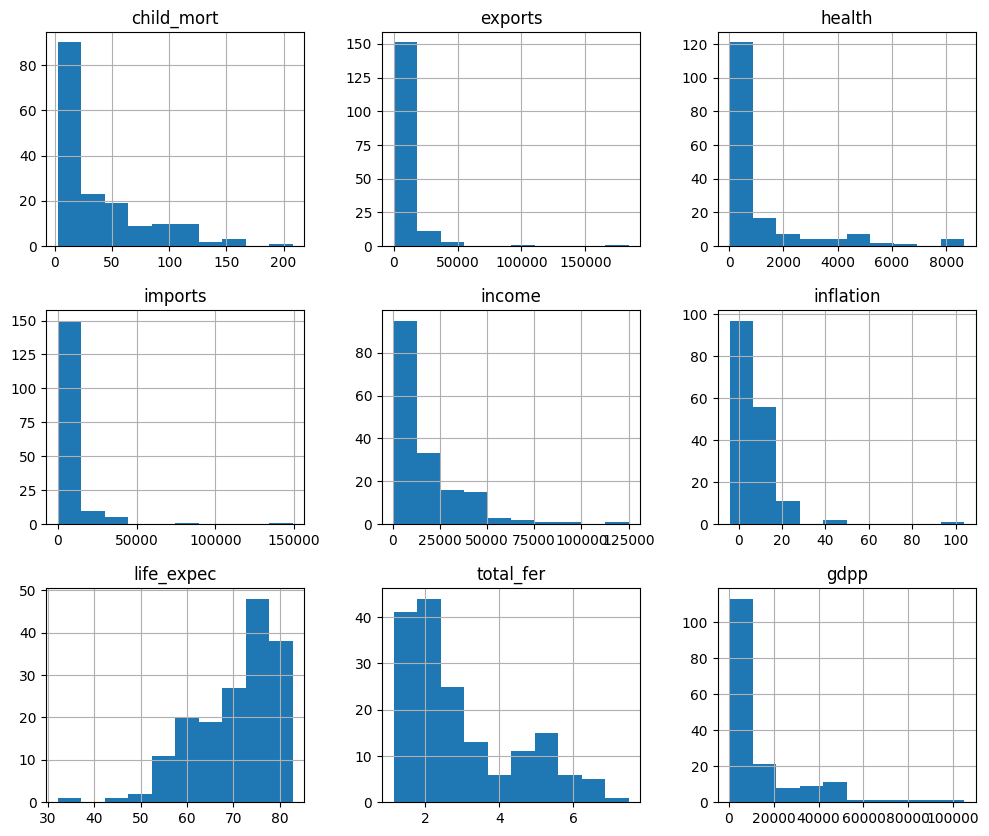

In [9]:
import seaborn as sb
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()

The distributions show noticeable differences in scale and spread across variables.

- `exports` contains a few outliers and ranges roughly from 0 to 200.
- `child_mort` has several extreme outliers and ranges up to around 200.
- `health` is relatively stable with only a small number of possible outliers and ranges from 0 to around 15.
- `income` contains strong outliers and spans a very large range, reaching above 125,000
- `imports` has several outliers and ranges up to around 150.
- `life_expec` contains a few outliers and reaches around 80 years.
- `total_fer` is relatively balanced with limited outliers and ranges up to around 7.
- `gdpp` shows a highly skewed distribution with major outliers reaching around 100,000.
- `inflation` has a few significant outliers and ranges up to nearly 100.
    

## Feature Scaling

Since the variables have very different scales, we standardize the numeric features before applying PCA and clustering methods. This prevents variables with large magnitudes from dominating the distance calculations.

In [10]:
from sklearn.preprocessing import StandardScaler
numeric_df = df.drop(columns=['country'])
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)
scaled_df = pd.DataFrame(scaled_data,columns=numeric_df.columns)
scaled_df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02
mean,-3.722904e-17,6.382120e-17,-2.659217e-17,4.254747e-17,-7.977650e-17,-1.063687e-17,3.696311e-16,3.044803e-16,5.850277e-17
std,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00
min,-8.871383e-01,-4.140371e-01,-5.812404e-01,-4.491604e-01,-8.603259e-01,-1.137852e+00,-4.337186e+00,-1.191250e+00,-6.968005e-01
25%,-7.466190e-01,-3.891452e-01,-5.446513e-01,-4.055539e-01,-7.174558e-01,-5.666409e-01,-5.927576e-01,-7.639023e-01,-6.366596e-01
50%,-4.717981e-01,-3.149097e-01,-4.091560e-01,-3.097338e-01,-3.738080e-01,-2.269504e-01,2.869576e-01,-3.564309e-01,-4.544309e-01
75%,5.926666e-01,-7.958645e-03,-4.442811e-02,7.713036e-02,2.942370e-01,2.816364e-01,7.042584e-01,6.175252e-01,5.942100e-02
max,4.221297e+00,9.839814e+00,4.235432e+00,9.716681e+00,5.611542e+00,9.129718e+00,1.380962e+00,3.009349e+00,5.036507e+00


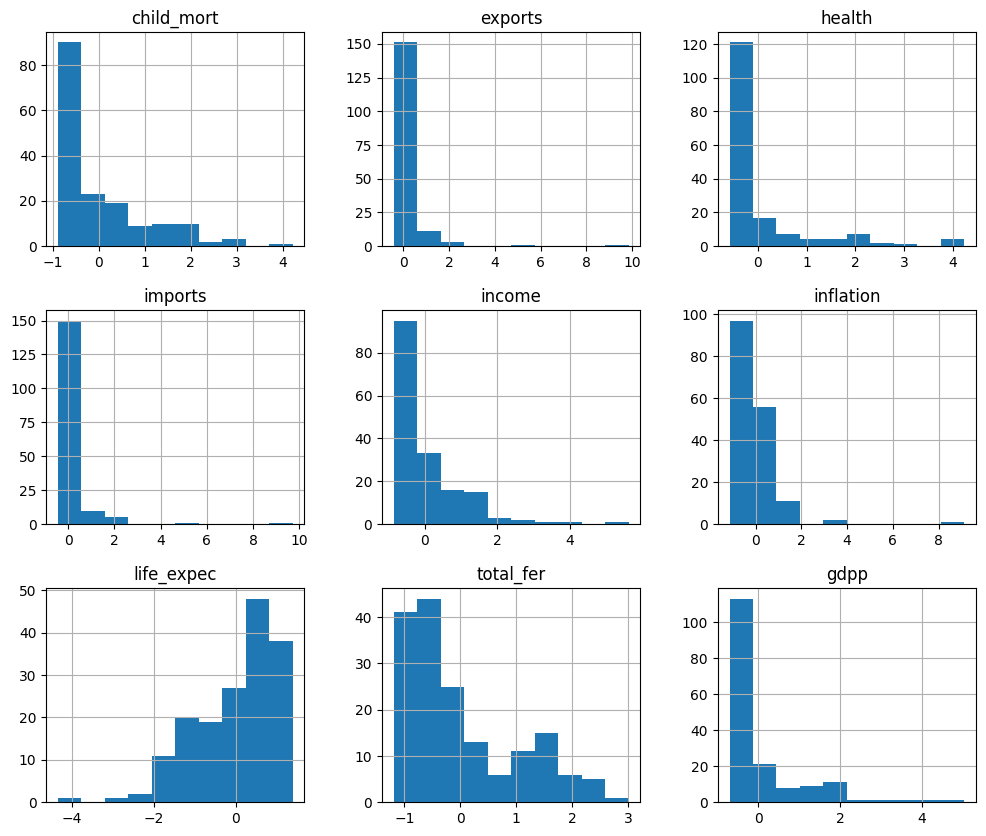

In [11]:
scaled_df.hist(figsize=(12,10))
plt.show()

The numerical features were standardized using StandardScaler. Each variable was transformed to have zero mean and unit variance. The resulting values are now on a comparable scale, making them suitable for PCA and clustering algorithms.

## Correlation Analysis

We visualize the correlation matrix to understand relationships between variables and identify strongly correlated features before applying PCA.

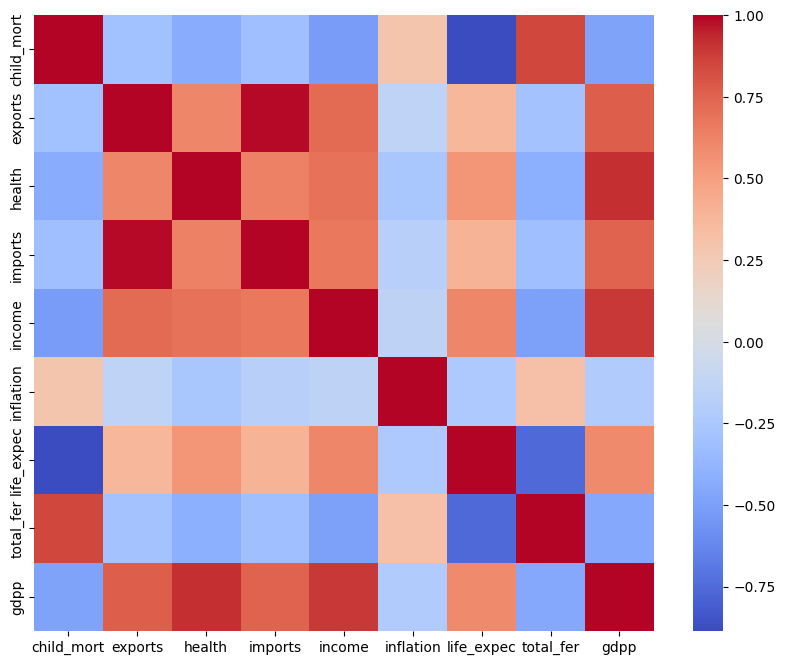

In [11]:
plt.figure(figsize=(10,8))
sb.heatmap(scaled_df.corr(),cmap='coolwarm')
plt.show()

## Correlation Insights

The heatmap reveals several meaningful relationships between variables.

- `income` and `gdpp` show a strong positive correlation.
- `total_fer` and `child_mort` show a moderate positive correlation.
- `exports` and `imports` display a noticeable positive relationship.
- `gdpp` has positive correlations with both `exports` and `health`.
- `income` also shows moderate positive relationships with `health`, `exports`, and `imports`.

These relationships suggest redundancy among some variables, making PCA a useful step before clustering.

## Feature Relationships

We analyze pairwise relationships and correlations between features to identify dependencies and redundancy in the dataset.

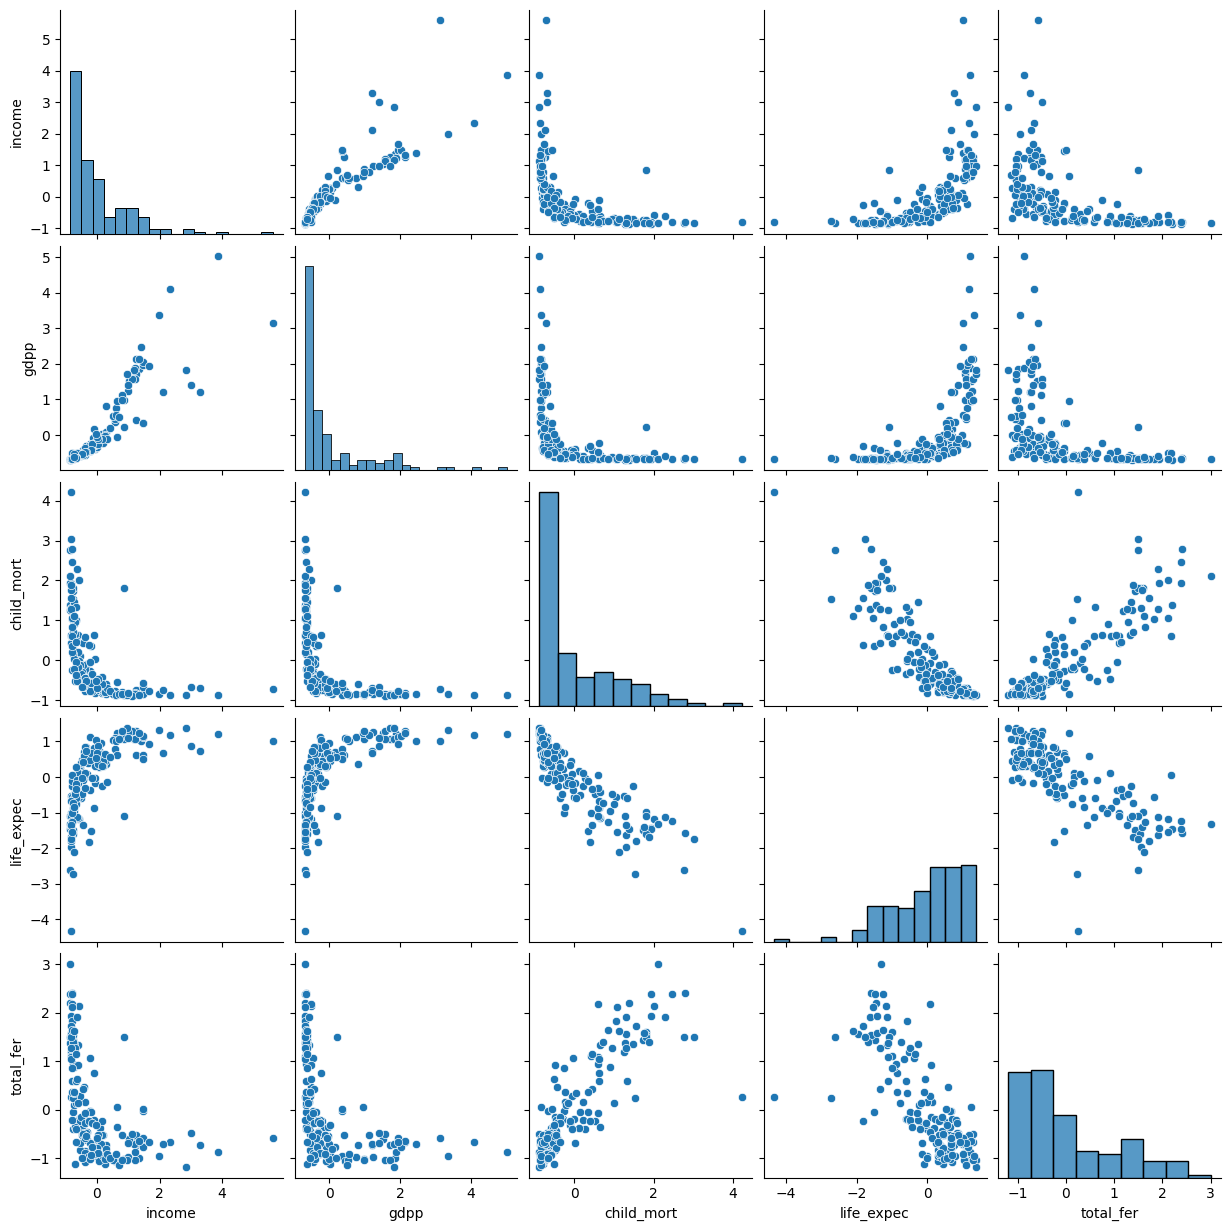

In [12]:
cols = ['income', 'gdpp', 'child_mort', 'life_expec', 'total_fer']
sb.pairplot(scaled_df[cols])

## Outlier Analysis

Boxplots are used to identify extreme values and potential outliers across all standardized features.

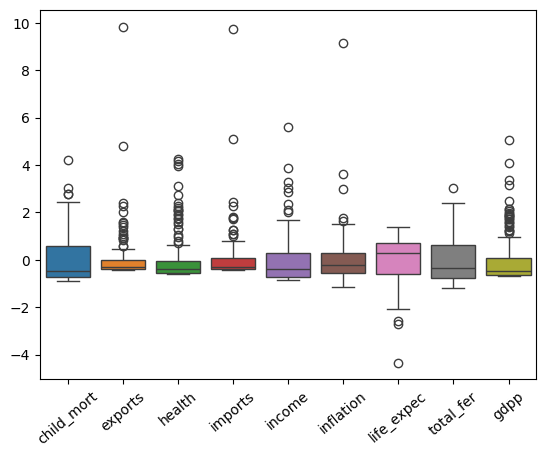

In [13]:
sb.boxplot(data=scaled_df)
plt.xticks(rotation=40)
plt.show()

Boxplot analysis on the standardized features shows that most variables contain outliers to some extent, with many of them appearing beyond the upper quartile range (Q3).

`child_mort` contains only a few outliers. `exports` shows a dense concentration of upper-side outliers along with one extremely distant observation. `health` does not contain major extreme values, but several compact outliers appear above the upper quartile.

`imports` contains a few upper-side outliers, including one very extreme observation similar to `exports`. `income` also contains a noticeable number of outliers compared to most variables.

`inflation` has several outliers, including one extremely distant value. `life_expec` contains a few lower-side outliers located below the first quartile range. `total_fer` shows only a very limited number of outliers.

`gdpp` contains many densely packed upper-side outliers, indicating the presence of countries with significantly higher GDP per capita compared to the majority of observations.

Overall, the boxplots suggest that the dataset contains several extreme economic and development-related observations, which should be considered carefully before clustering.

## Dimensionality Reduction with PCA

Before clustering, we apply Principal Component Analysis (PCA) to reduce redundancy among correlated variables and create a lower-dimensional representation of the dataset while preserving most of the original information.

In [14]:
from sklearn.decomposition import PCA
import numpy as np
pca = PCA()
pca.fit(scaled_df)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [15]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print(explained_variance)
print(cumulative_variance)

[5.89372984e-01 1.84451685e-01 9.91147170e-02 6.07227801e-02
 3.02917253e-02 2.45982702e-02 9.39743701e-03 1.55641971e-03
 4.93981394e-04]
[0.58937298 0.77382467 0.87293939 0.93366217 0.96395389 0.98855216
 0.9979496  0.99950602 1.        ]


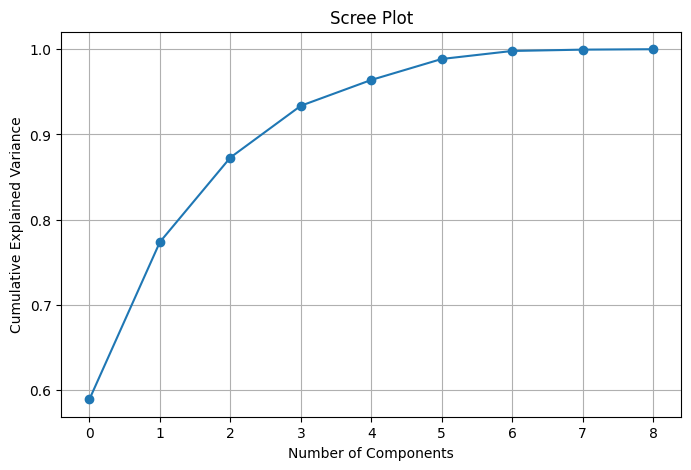

In [16]:
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance,marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()

The first four principal components explain more than 93% of the total variance. Therefore, four components are retained for the clustering stage.

In [17]:
pca = PCA(n_components=4)
pca_data = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2','PC3','PC4']
)
pca_df['country'] = df['country']

After selecting 4 principal components based on the cumulative explained variance, the dataset was transformed into a lower-dimensional representation using PCA.

A new dataframe was created containing the four principal components (PC1–PC4) along with the corresponding country names. This transformed dataset will be used for outlier detection and clustering.

## Outlier Detection on Principal Components

After transforming the dataset using PCA, we analyze the distribution of the principal components to identify extreme observations.

Outliers are detected using the IQR method on the PCA components. Removing these extreme points helps improve clustering stability and reduces the impact of unusually distant observations.

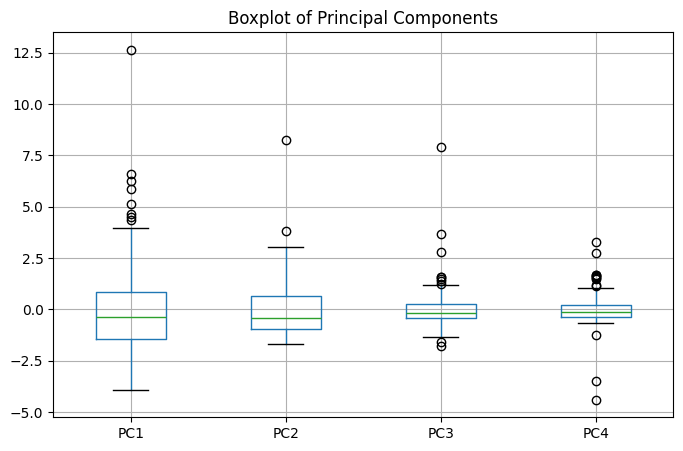

In [18]:
pca_df.boxplot(figsize=(8,5))
plt.title("Boxplot of Principal Components")
plt.show()

In [19]:
Q1 = pca_df[['PC1','PC2','PC3','PC4']].quantile(0.25)
Q3 = pca_df[['PC1','PC2','PC3','PC4']].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [20]:
mask = ~(
    (pca_df[['PC1','PC2','PC3','PC4']] < lower_bound) |
    (pca_df[['PC1','PC2','PC3','PC4']] > upper_bound)
).any(axis=1)

clean_pca_df = pca_df[mask]

outliers_df = pca_df[~mask]

In [21]:
print(clean_pca_df.shape)
print(outliers_df.shape)

(141, 5)
(26, 5)


In [22]:
outliers_df['country']

5                     Argentina
7                     Australia
23                       Brunei
29                       Canada
31     Central African Republic
44                      Denmark
54                       France
58                      Germany
66                        Haiti
73                      Ireland
77                        Japan
91                   Luxembourg
98                        Malta
103                    Mongolia
110                 Netherlands
113                     Nigeria
114                      Norway
123                       Qatar
128                Saudi Arabia
133                   Singapore
140                   Sri Lanka
144                      Sweden
145                 Switzerland
149                 Timor-Leste
159               United States
163                   Venezuela
Name: country, dtype: str

Outlier detection was performed on the principal components using the IQR method (1.5 × IQR rule).

After removing extreme observations, the cleaned dataset contains 141 countries, while 26 countries were identified as outliers and stored separately for further inspection.

Several highly developed countries such as Canada, Norway, Switzerland, Singapore, Qatar, and the United States appeared as outliers due to their exceptionally high economic indicators.

Some countries with severe development challenges, including Haiti, Central African Republic, Nigeria, and Timor-Leste, were also detected as outliers because of extreme socio-economic conditions.

These outliers may strongly influence clustering results, therefore they are temporarily removed before applying clustering algorithms.

Text(0.5, 1.0, 'Boxplot After Outlier Removal')

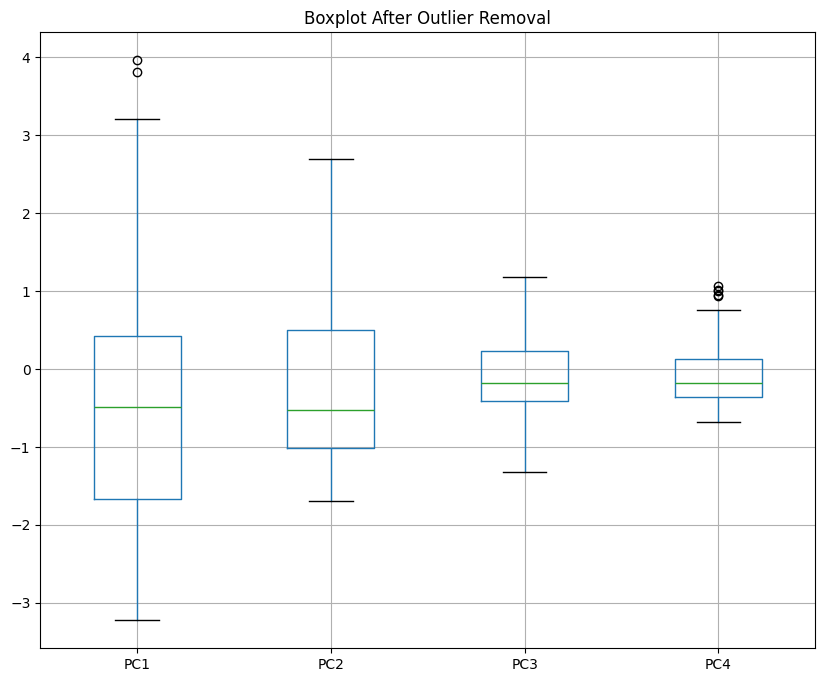

In [23]:
clean_pca_df.boxplot(figsize=(10,8))
plt.title("Boxplot After Outlier Removal")

The boxplot of the cleaned PCA dataset shows that most extreme outliers have been successfully removed using the IQR method. A few remaining mild outliers are still visible, which is expected in real-world data and does not significantly affect the stability of downstream clustering.

## K-Means Clustering

K-Means clustering is applied to the PCA-transformed dataset in order to group countries with similar socio-economic characteristics.

To determine an appropriate number of clusters, both the silhouette score and the elbow method are evaluated across multiple values of k.

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []

K = range(2,11)
X = clean_pca_df[['PC1','PC2','PC3','PC4']]

for k in K:
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X,labels)
    )
print(silhouette_scores,inertia)


[0.480597966106994, 0.49608268045448095, 0.3988628191423786, 0.3371357100531729, 0.3377513903605291, 0.35371755123351345, 0.32443333382251643, 0.2857420735079388, 0.29167773235448496] [255.46739185733492, 143.1608298572147, 108.74623187223196, 91.67283542231733, 79.22810169546538, 68.46318638617953, 61.62917963757827, 57.498502708772975, 53.90637312897821]


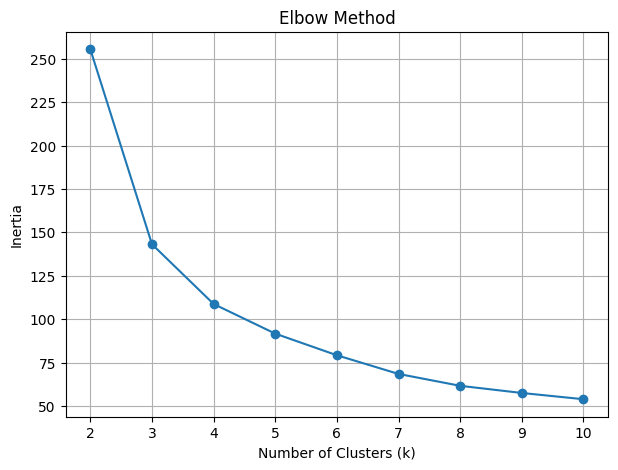

In [25]:
plt.figure(figsize=(7,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()

plt.show()

## Elbow Method Analysis

The inertia decreases as the number of clusters increases, which is expected because adding more clusters reduces the within-cluster distance. However, the rate of improvement starts to slow down after approximately k = 3 or k = 4, forming an elbow point. This suggests that using more than 4 clusters may not provide significant additional structure in the data.

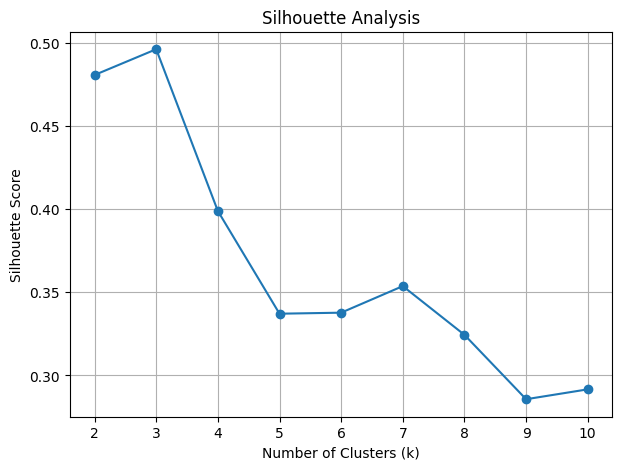

In [26]:
plt.figure(figsize=(7,5))

plt.plot(K, silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid()

plt.show()

## Silhouette Score Analysis

The silhouette score reaches its highest value at k = 3, indicating that this clustering solution provides the best separation and cohesion among clusters. As k increases beyond 3, the silhouette score gradually decreases, suggesting that additional clusters lead to more overlap and weaker cluster structure.

In [27]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=42)

clean_pca_df['cluster'] = kmeans.fit_predict(
        clean_pca_df[['PC1','PC2','PC3','PC4']]
)

In [32]:
clean_pca_df['cluster'].value_counts()

cluster
1    76
2    44
0    21
Name: count, dtype: int64

In [31]:
clean_pca_df.head()

,PC1,PC2,PC3,PC4,country,cluster
0,-2.635575,1.472267,-0.549489,0.242326,Afghanistan,2
1,-0.024206,-1.429892,-0.014123,-0.450645,Albania,1
2,-0.459557,-0.675495,0.959355,-0.218456,Algeria,1
3,-2.722630,2.172332,0.600215,0.433978,Angola,2
4,0.648597,-1.023437,-0.257430,-0.289201,Antigua and Barbuda,1


## Cluster Distribution (K = 3)

The K-Means clustering result shows the following distribution:

- Cluster 1: 76 countries (largest group)
- Cluster 2: 44 countries
- Cluster 0: 21 countries (smallest group)

This indicates an imbalanced but structured grouping, where most countries fall into a medium cluster, while smaller clusters likely represent extreme socio-economic conditions (either highly developed or underdeveloped countries).

## Cluster Interpretation (Cluster Profiling)

After assigning each country to a cluster using K-Means, we now analyze the characteristics of each cluster. This is done by computing the average value of the original socio-economic variables within each cluster to understand what each group represents in terms of development level.

In [37]:
features = df.columns.drop('country')

cluster_means = clean_pca_df[['country', 'cluster']].merge(df, on='country')
cluster_summary = cluster_means.groupby('cluster')[features].mean()

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.752381,15073.752381,2557.891429,13801.204762,36866.666667,3.191619,79.142857,1.826190,31080.952381
1,22.417105,2616.788007,383.481663,2858.415672,11405.526316,6.190250,72.867105,2.265658,5890.947368
2,87.447727,940.282841,113.670425,857.833114,4038.295455,9.858523,59.825000,4.977500,1922.818182



K-Means clustering with 3 clusters produced a clear and interpretable segmentation of countries based on socio-economic indicators.

- Cluster 0 represents developed countries with high income, high GDP per capita, high life expectancy, and low child mortality.
- Cluster 1 represents developing countries with moderate economic and health indicators.
- Cluster 2 represents low-income countries with high child mortality, low income, and low GDP per capita.

Overall, the k = 3 solution provides a meaningful and well-separated structure that aligns well with real-world economic development levels.

In [38]:
from sklearn.cluster import KMeans

kmeans4 = KMeans(n_clusters=4, random_state=42)

clean_pca_df['cluster_k4'] = kmeans4.fit_predict(
    clean_pca_df[['PC1','PC2','PC3','PC4']]
)

In [39]:
clean_pca_df['cluster_k4'].value_counts()

cluster_k4
3    54
1    35
2    33
0    19
Name: count, dtype: int64


K-Means with k = 4 produced a more granular segmentation of countries compared to k = 3.

Cluster distribution:

- Cluster 3: 54 countries
- Cluster 1: 35 countries
- Cluster 2: 33 countries
- Cluster 0: 19 countries

Compared to k = 3, the dataset is now split into smaller and more detailed groups, which may capture finer differences between countries but also risks over-segmentation.

## Does Increasing k from 3 to 4 Improve the Clustering?

The transition from k = 3 to k = 4 introduces an additional cluster that further splits the existing groups into smaller segments. While this increases granularity, it does not necessarily improve the interpretability of the results.

Based on the silhouette analysis and the structure observed in k = 3, the three-cluster solution already provides a clear and meaningful separation between developed, developing, and low-income countries. The additional split in k = 4 appears to refine existing groups rather than reveal a fundamentally new structure.

Therefore, k = 4 may introduce unnecessary complexity without significantly improving the quality or interpretability of the clustering.

In [41]:
features = df.columns.drop('country')

k4_data = clean_pca_df[['country', 'cluster_k4']].merge(df, on='country')
k4_summary = k4_data.groupby('cluster_k4')[features].mean()

k4_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_k4,,,,,,,,,
0,5.373684,15326.468421,2722.208947,14155.731579,37036.842105,2.681000,79.494737,1.790526,32463.157895
1,43.625714,1200.198501,177.144483,1272.504088,6562.285714,8.388286,66.631429,3.245714,2962.342857
2,97.972727,767.295939,69.227461,679.071061,3031.060606,10.179242,59.124242,5.349091,1387.090909
3,15.001852,3671.602222,512.135037,3868.586296,14542.592593,5.385444,74.788889,1.952037,7754.814815


Although k = 4 provides a more detailed segmentation of countries, it mainly splits the developing group into finer subgroups without introducing fundamentally new structure. Therefore, it increases complexity without significantly improving interpretability. As a result, k = 3 remains the most meaningful and balanced clustering solution.

## Hierarchical Clustering

In this section, we apply hierarchical clustering to the PCA-transformed dataset. Unlike K-Means, hierarchical clustering does not require predefining cluster centers. Instead, it builds clusters step by step by merging data points based on distance.

We will experiment with different linkage methods (single and complete) and compare their clustering behavior with the K-Means results in order to evaluate which method provides more meaningful and stable groupings of countries.

In [45]:
from sklearn.cluster import AgglomerativeClustering

X = clean_pca_df[['PC1','PC2','PC3','PC4']]
single = AgglomerativeClustering(n_clusters=3,linkage='single')
clean_pca_df['h_single'] = single.fit_predict(X)

complete = AgglomerativeClustering(n_clusters=3, linkage='complete')
clean_pca_df['h_complete'] = complete.fit_predict(X)

In [46]:
clean_pca_df['h_single'].value_counts(), clean_pca_df['h_complete'].value_counts()

(h_single
 0    138
 2      2
 1      1
 Name: count, dtype: int64,
 h_complete
 2    76
 1    44
 0    21
 Name: count, dtype: int64)

## Hierarchical Clustering Results

Two linkage methods were tested: single linkage and complete linkage.

### Single Linkage
The single linkage method produced an imbalanced clustering:

- Cluster 0: 138 countries
- Cluster 2: 2 countries
- Cluster 1: 1 country

This indicates a strong chaining effect, where most points are merged into one large cluster, making the solution less useful for interpretation.

### Complete Linkage
The complete linkage method produced a much more balanced clustering:

- Cluster 2: 76 countries
- Cluster 1: 44 countries
- Cluster 0: 21 countries

This distribution is very similar to the K-Means (k=3) result and suggests a more meaningful and stable grouping of countries.


At this stage, we evaluate whether hierarchical clustering (complete linkage) can replace K-Means as a more suitable method for representing the structure of countries, or whether K-Means remains the more appropriate choice.

In [48]:
features = df.columns.drop('country')

h_data = clean_pca_df[['country', 'h_complete']].merge(df, on='country')
h_summary = h_data.groupby('h_complete')[features].mean()

h_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
h_complete,,,,,,,,,
0,5.752381,15073.752381,2557.891429,13801.204762,36866.666667,3.191619,79.142857,1.826190,31080.952381
1,87.447727,940.282841,113.670425,857.833114,4038.295455,9.858523,59.825000,4.977500,1922.818182
2,22.417105,2616.788007,383.481663,2858.415672,11405.526316,6.190250,72.867105,2.265658,5890.947368


## Comparison: K-Means vs Hierarchical Clustering (Complete Linkage)

Both K-Means (k = 3) and Hierarchical Clustering (complete linkage) produce very similar country groupings in terms of economic and social indicators.

### Cluster Structure Comparison

- Both methods identify a high-development cluster with high income, high GDP per capita, high life expectancy, and low child mortality.
- Both methods identify a low-development cluster with low income, high fertility, high child mortality, and low GDP per capita.
- The middle cluster represents developing countries with intermediate values across all indicators.

### Interpretation

The similarity between the two methods indicates that the underlying structure of the data is stable and well-defined. However, K-Means provides slightly more balanced and interpretable clusters, while hierarchical clustering offers a useful validation of the results.

### Conclusion

Both methods are consistent, but K-Means is selected as the final model due to its stability, interpretability, and alignment with silhouette analysis results.

## DBSCAN Clustering and Parameter Sensitivity

In this section, we apply DBSCAN to identify density-based clusters and detect outliers (noise points). Since DBSCAN is highly sensitive to its parameters, especially `eps` and `min_samples`, we also analyze how changing these values affects the number of detected clusters and outliers.

In [92]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.8, min_samples=5)
clean_pca_df['dbscan'] = db.fit_predict(clean_pca_df[['PC1','PC2','PC3','PC4']])

In [93]:
clean_pca_df['dbscan'].value_counts()

dbscan
 0    131
-1     10
Name: count, dtype: int64

DBSCAN revealed that the dataset consists of one large dense group of countries and a smaller set of outliers. The number of detected noise points changes significantly with different parameter settings, showing that DBSCAN is sensitive to `min_samples`.

This suggests that while DBSCAN is useful for detecting anomalies, it is less stable for defining global cluster structure in this dataset compared to K-Means and hierarchical clustering.

In [96]:
outliers = clean_pca_df[clean_pca_df['dbscan'] == -1]

outliers_data = outliers[['country']].merge(df, on='country')

outliers_data

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Angola,119.0,2199.190,100.605,1514.370,5900,22.400,60.1,6.16,3530
1,Austria,4.3,24059.700,5159.000,22418.200,43200,0.873,80.5,1.44,46900
2,Bahrain,8.6,14386.500,1028.790,10536.300,41100,7.440,76.0,2.16,20700
3,Belgium,4.5,33921.600,4750.800,33166.800,41100,1.880,80.0,1.86,44400
4,Equatorial Guinea,111.0,14671.800,766.080,10071.900,33700,24.900,60.9,5.21,17100
5,Finland,3.0,17879.400,4134.900,17278.800,39800,0.351,80.0,1.87,46200
6,Iceland,2.6,22374.600,3938.600,18142.700,38800,5.470,82.0,2.20,41900
7,Kuwait,10.8,25679.500,1012.550,11704.000,75200,11.200,78.2,2.21,38500
8,Sierra Leone,160.0,67.032,52.269,137.655,1220,17.200,55.0,5.20,399
9,United Arab Emirates,8.6,27195.000,1281.000,22260.000,57600,12.500,76.5,1.87,35000


In [97]:
outliers_data[['child_mort','income','gdpp','life_expec']].describe()

,child_mort,income,gdpp,life_expec
count,10.000000,10.000000,10.000000,10.000000
mean,43.240000,37762.000000,29462.900000,72.920000
std,61.195574,21651.897428,17704.881113,10.112127
min,2.600000,1220.000000,399.000000,55.000000
25%,4.350000,34975.000000,18000.000000,64.675000
50%,8.600000,40450.000000,36750.000000,77.350000
75%,85.950000,42675.000000,43775.000000,80.000000
max,160.000000,75200.000000,46900.000000,82.000000


## Analysis of DBSCAN Outliers

The DBSCAN algorithm identified 10 countries as outliers, which represent extreme deviations from the main global development structure.

These outliers include both highly developed economies (e.g. Austria, Belgium, Finland, Iceland, UAE, Kuwait) and low-income countries (e.g. Angola, Sierra Leone), indicating that DBSCAN is capturing extremes on both ends of the development spectrum.

### Statistical Interpretation

The summary statistics show:

- Very high variability in child mortality (ranging from 2.6 to 160)
- Extremely wide range in income and GDP per capita
- Life expectancy varies from 55 to 82 years

### Key Insight

These outliers are not simply "bad" or "good" countries, but rather represent **extreme economic and social profiles** that do not fit into the main clustered structure of the dataset.

This confirms that DBSCAN is effective in identifying countries with unusual development patterns, but it does not directly separate them into meaningful development groups like K-Means.

## Comparison of DBSCAN Outliers with K-Means Clusters

In this section, we compare the countries identified as outliers by DBSCAN with the clusters obtained from K-Means to understand whether these extreme observations are already captured within the standard clustering structure or represent genuinely distinct cases.

In [100]:
dbscan_outliers = outliers_data[['country']]

kmeans_check = clean_pca_df[['country', 'cluster']]
comparison = dbscan_outliers.merge(kmeans_check, on='country', how='left')

comparison

,country,cluster
0,Angola,2
1,Austria,0
2,Bahrain,0
3,Belgium,0
4,Equatorial Guinea,2
5,Finland,0
6,Iceland,0
7,Kuwait,0
8,Sierra Leone,2
9,United Arab Emirates,0


Comparing the DBSCAN outliers with the K-Means clusters reveals that the two methods capture different aspects of the data.

Countries such as Angola, Sierra Leone, and Equatorial Guinea were assigned to the low-development cluster by K-Means and were also identified as outliers by DBSCAN. This suggests that these countries represent extreme cases of development challenges.

In contrast, countries such as Austria, Belgium, Finland, Iceland, Kuwait, Bahrain, and the United Arab Emirates were assigned to the developed-country cluster by K-Means but were still detected as outliers by DBSCAN. This indicates that they possess unusually strong or distinctive economic characteristics compared to the rest of the developed countries.

Therefore, DBSCAN does not simply identify underdeveloped countries. Instead, it highlights observations that are significantly different from the overall population, whether they are exceptionally disadvantaged or exceptionally prosperous.

This result suggests that K-Means is more suitable for identifying development levels, while DBSCAN is valuable for detecting exceptional countries that deserve separate investigation.

## Identifying Countries Most in Need of Aid

After comparing multiple clustering approaches, we now use the final clustering results to identify countries facing the most severe development challenges. The goal is to determine which countries should be prioritised for international aid based on their socio-economic indicators.

In [101]:
high_need_countries = clean_pca_df[clean_pca_df['cluster'] == 2]

high_need_countries[['country']].sort_values('country')

,country
0,Afghanistan
3,Angola
17,Benin
21,Botswana
25,Burkina Faso
26,Burundi
28,Cameroon
32,Chad
36,Comoros
37,"Congo, Dem. Rep."



Cluster 2 contains countries with the lowest income and GDP per capita, the highest child mortality rates, the lowest life expectancy, and the highest fertility rates among all clusters.

The countries in this cluster are concentrated primarily in Sub-Saharan Africa, along with a small number of countries from other developing regions. This pattern is consistent with the cluster statistics and confirms that Cluster 2 represents the group facing the most severe development challenges.

Therefore, countries belonging to Cluster 2 should be considered the highest priority candidates for international aid and development support.

## Creating an Aid Priority Score

Although Cluster 2 already represents the countries with the greatest development challenges, countries within this cluster are not equally vulnerable.

To identify the highest-priority candidates for aid, a composite Aid Priority Score is created using multiple indicators. Countries with higher child mortality and fertility rates, lower income, lower GDP per capita, and lower life expectancy receive higher scores.

In [102]:
from sklearn.preprocessing import StandardScaler

aid_features = [
    'child_mort',
    'income',
    'gdpp',
    'life_expec',
    'total_fer'
]

aid_df = cluster_means[cluster_means['cluster'] == 2].copy()

scaled_aid = StandardScaler().fit_transform(aid_df[aid_features])

scaled_aid = pd.DataFrame(
    scaled_aid,
    columns=aid_features,
    index=aid_df.index
)

aid_df['aid_score'] = (
    scaled_aid['child_mort']
    + scaled_aid['total_fer']
    - scaled_aid['income']
    - scaled_aid['gdpp']
    - scaled_aid['life_expec']
)

aid_df = aid_df.sort_values(
    'aid_score',
    ascending=False
)

aid_df[
    ['country', 'aid_score']
].head(15)

,country,aid_score
27,Chad,5.242956
97,Niger,5.042340
113,Sierra Leone,4.851255
32,"Congo, Dem. Rep.",4.190771
85,Mali,4.149841
92,Mozambique,3.284349
22,Burkina Faso,3.218387
23,Burundi,3.088553
82,Malawi,2.947660
56,Guinea-Bissau,2.869939


## Aid Priority Ranking

To prioritise countries within the high-need cluster, a composite Aid Priority Score was constructed using child mortality, fertility rate, income, GDP per capita, and life expectancy.

Countries with higher child mortality and fertility, combined with lower income, lower GDP per capita, and lower life expectancy, received higher scores.

The ranking identified Chad, Niger, Sierra Leone, Democratic Republic of the Congo, and Mali as the countries facing the most severe development challenges. These countries consistently exhibit poor socio-economic indicators and should therefore receive the highest priority for international aid.

This ranking provides a more balanced assessment than relying on a single variable, since it considers multiple dimensions of development simultaneously.

## Final Recommendation

Based on the clustering analysis, Cluster 2 was identified as the group of countries facing the most severe development challenges. These countries are characterised by low income, low GDP per capita, high child mortality, low life expectancy, and high fertility rates.

Among them, the highest-priority countries according to the Aid Priority Score are:

1. Chad
2. Niger
3. Sierra Leone
4. Democratic Republic of the Congo
5. Mali
6. Mozambique
7. Burkina Faso
8. Burundi
9. Malawi
10. Guinea-Bissau

These countries should be prioritised for aid allocation because they consistently perform poorly across multiple development indicators and represent the greatest humanitarian and economic need within the dataset.